# Deriving QA thresholds

The procedure, run top to bottom: measure the [validation visits](validation-visits.md)
with the current code, derive `WARN`/`FAIL` thresholds from the known-good visits, check
them against the known-bad ones, and review them for adoption. Run it whenever the metrics
code, the visit set or the instrument changes. The rules behind it are in
[`qa-principles.md`](qa-principles.md).

Sections 3 and 4 run `pipetask`. Section 4 is the only one that writes to the Butler (one
new collection), and only when `RUN_PIPELINE` is set. Everything else reads.

**Start Jupyter from a shell with the stack set up**, so that `pipetask` and the Butler are
available to the kernel:

```bash
source /path/to/stack/loadLSST.bash
setup -r /path/to/drp_stella
setup -r /path/to/drp_qa
cd /path/to/drp_qa/docs
jupyter lab qa-thresholds.ipynb
```

Set the inputs in section 1, then run all cells. When it has run, commit it with its
outputs (section 9): they are the record of what the
thresholds were derived from.

Confirm the setup; the output is the record of what was run:

In [1]:
!eups list --setup drp_stella

   w.2026.40  	setup


In [2]:
!eups list --setup drp_qa

   LOCAL:/work/wtg/drp_qa 	setup


## 1. Inputs

The only cell to edit. Each run writes a numbered collection, `u/$USER/qa-thresholds/001`,
`002`, ..., never one that mixes code versions such as `qaActor/reductions`.
`RUN_PIPELINE = True` makes the next numbered run; `False` reads the latest one again. To
read an older run, set `RUN_NAME` to its collection.

In [3]:
import os

# Likely to change
RUN_PIPELINE = False  # True: run imageQualityQa into a new numbered collection (section 4)
RUN_NAME = None  # optional: an older run to read, e.g. "u/someone/qa-thresholds/002"

# Rarely change
PREFIX = f"u/{os.environ['USER']}/qa-thresholds"
BUTLER = "/work/datastore"
INPUTS = "PFS/defaults"  # raw data and calibrations; the notebook reduces everything itself
FILES = "~/.cache/drp_qa"  # pipetask logs and the metrics cache
# "sequence": cosmicray combines each sequence's exposures, as drpActor does, so the
# thresholds describe the reductions qaActor gates. "separate": each exposure alone, to
# measure how much grouping moves the metrics (PIPE2D-1609).
COSMIC_RAY_GROUPING = "sequence"  # or 'separate'

## Set up

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pfs.drp.qa.metrics.calibration import (
    DEFAULT_METRICS,
    METRIC_SPECS,
    calibrate,
    compareRuns,
    labelRows,
    summarizeRuns,
    writeThresholds,
)
from pfs.drp.qa.metrics.readers import chooseRun, readMetrics
from pfs.drp.qa.metrics.validationVisits import (
    loadValidationVisits,
    sequenceGroups,
    sequenceTypeMismatches,
    unmatchedEntries,
    visitExpression,
)
from pfs.drp.qa.plotting import plotThresholds

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

existing = !butler query-collections {BUTLER} "{PREFIX}/*"
COLLECTION = chooseRun(existing, PREFIX, newRun=RUN_PIPELINE, runName=RUN_NAME)
PIPELINE = "../pipelines/qaThresholds.yaml"
FILES = Path(FILES).expanduser()
FILES.mkdir(parents=True, exist_ok=True)
STEM = COLLECTION.replace("/", "_")
CACHE = FILES / f"iqQaMetrics-{STEM}.parquet"
METRICS = [*DEFAULT_METRICS, "nLines"]
print(f"collection: {COLLECTION}")
print(f"files:      {FILES}")

collection: u/wtg/qa-thresholds/003
files:      /home/wtg/.cache/drp_qa


## 2. The visits

From the YAML, never typed by hand, in two passes. `drpActor` sets the reduction config by
sequence type (`ics_drpActor`, `engine.newVisitGroup`), and the thresholds must describe the
data as live QA sees it, so each pass uses that sequence type's config.

In [5]:
visitSet = loadValidationVisits()
print(
    f"{len(visitSet.knownGood)} known_good entries ({len(visitSet.goodVisits)} visits), "
    f"{len(visitSet.confirmedBad)} known_bad, {len(visitSet.unconfirmedBad)} unconfirmed; "
    f"{len(visitSet.visits)} visits"
)

# drpActor's per-sequence-type config overrides.
PASSES = {
    "arcs and traces": (
        visitSet.visitsOfType("scienceArc", "scienceTrace"),
        {
            "reduceExposure:requireAdjustDetectorMap": False,
            "isr:h4.quickCDS": True,
            "cosmicray:doNormalizeChiRms": True,
        },
    ),
    "sky": (
        visitSet.visitsOfType("scienceObject"),
        {
            "reduceExposure:requireAdjustDetectorMap": True,
            "isr:h4.quickCDS": False,
            "cosmicray:doNormalizeChiRms": True,
        },
    ),
}


def passArgs(name, visits, config):
    """Return the config options and the -d expression of one pass.

    cosmicray combines repeated exposures. drpActor reduces one sequence at a time, so
    by default each sequence is one group; with COSMIC_RAY_GROUPING = "separate" each
    exposure is its own. Written to a config file.
    """
    groups = FILES / f"cosmicray-{STEM}-{name.replace(' ', '_')}.py"
    if COSMIC_RAY_GROUPING == "sequence":
        groups.write_text(
            f'config.grouping = "manual"\nconfig.groups = {sequenceGroups(visitSet, visits)!r}\n'
        )
    elif COSMIC_RAY_GROUPING == "separate":
        groups.write_text('config.grouping = "separate"\n')
    else:
        raise ValueError(f"COSMIC_RAY_GROUPING={COSMIC_RAY_GROUPING!r}: use 'sequence' or 'separate'")
    options = " ".join(f"-c {key}={value}" for key, value in config.items())
    return f"{options} -C cosmicray:{groups}", f"instrument = 'PFS' AND {visitExpression(visits)}"


for name, (visits, config) in PASSES.items():
    options, where = passArgs(name, visits, config)
    print(f"{name}: {len(visits)} visits; {options}")
    print(f"    {where}")

44 known_good entries (115 visits), 42 known_bad, 2 unconfirmed; 132 visits
arcs and traces: 107 visits; -c reduceExposure:requireAdjustDetectorMap=False -c isr:h4.quickCDS=True -c cosmicray:doNormalizeChiRms=True -C cosmicray:/home/wtg/.cache/drp_qa/cosmicray-u_wtg_qa-thresholds_003-arcs_and_traces.py
    instrument = 'PFS' AND visit IN (133025..133055, 133532..133533, 133536..133537, 134338..134339, 135828..135850, 139971, 140005..140006, 140032, 140035, 140124..140148, 140477, 140640, 140649, 140651, 149217, 149398, 149881, 149883, 150115..150116, 150367, 150413, 150641..150642, 150661, 150779, 150782)
sky: 25 visits; -c reduceExposure:requireAdjustDetectorMap=True -c isr:h4.quickCDS=False -c cosmicray:doNormalizeChiRms=True -C cosmicray:/home/wtg/.cache/drp_qa/cosmicray-u_wtg_qa-thresholds_003-sky.py
    instrument = 'PFS' AND visit IN (134334..134337, 134880..134886, 135275..135279, 148908..148911, 150840..150844)


## 3. Check the inputs exist

Build each pass's graph without running it. The pipeline reduces from raw data (isr,
cosmicray, reduceExposure) and then runs `imageQualityQa`: isr, reduceExposure and
`imageQualityQa` once per detector, and cosmicray once per camera and sequence, since it
combines a sequence's repeated exposures. For the current set that is about 4,700 quanta
over about 1,400 detectors. Far fewer means raw data or
calibrations are missing from `INPUTS`. Section 5 lists any visit that ends up with no
metrics.

In [6]:
for name, (visits, config) in PASSES.items():
    options, where = passArgs(name, visits, config)
    log = FILES / f"qgraph-{STEM}-{name.replace(' ', '_')}.log"
    print(f"{name}:")
    !pipetask qgraph -b {BUTLER} -p {PIPELINE} -i {INPUTS} -o {COLLECTION} {options} -d "{where}" > {log} 2>&1
    !grep -iE "quanta|error" {log} | tail -n 5

arcs and traces:
lsst.pipe.base.quantum_graph_builder INFO: Generated 558 quanta for task cosmicray (580 removed by adjust_all_quanta).
lsst.pipe.base.quantum_graph_builder INFO: Generated 1138 quanta for task reduceExposure.
lsst.pipe.base.quantum_graph_builder INFO: Generated 1138 quanta for task imageQualityQa.
lsst.ctrl.mpexec.cli.utils INFO: QuantumGraph contains 3972 quanta for 4 tasks
Quanta     Tasks     
sky:
lsst.pipe.base.quantum_graph_builder INFO: Generated 72 quanta for task cosmicray (228 removed by adjust_all_quanta).
lsst.pipe.base.quantum_graph_builder INFO: Generated 300 quanta for task reduceExposure.
lsst.pipe.base.quantum_graph_builder INFO: Generated 300 quanta for task imageQualityQa.
lsst.ctrl.mpexec.cli.utils INFO: QuantumGraph contains 972 quanta for 4 tasks
Quanta     Tasks     


## 4. Reduce and measure

Only with `RUN_PIPELINE = True` (section 1), into the next numbered collection, which the
set-up cell chose (it refuses `RUN_PIPELINE` with `RUN_NAME`, which would write into an
older run). Each pass adds a run to that collection. Running all cells again with
`RUN_PIPELINE` still set makes another numbered run: set it back to `False` to re-read this
one. The full logs go to files; the next cell reports their outcome.

In [7]:
if RUN_PIPELINE:
    for name, (visits, config) in PASSES.items():
        options, where = passArgs(name, visits, config)
        log = FILES / f"pipetask-{STEM}-{name.replace(' ', '_')}.log"
        print(f"{name}:")
        !pipetask --long-log --log-level PFS=INFO run -j 15 -b {BUTLER} -p {PIPELINE} -i {INPUTS} -o {COLLECTION} {options} -d "{where}" > {log} 2>&1
        !tail -n 3 {log}
else:
    print(f"RUN_PIPELINE is False: using the existing {COLLECTION}")

RUN_PIPELINE is False: using the existing u/wtg/qa-thresholds/003


The outcome of each pass, read from its log file so that it is recorded here even when
the run finished with the notebook closed: the executed and failed quanta.

In [18]:
for name in PASSES:
    log = FILES / f"pipetask-{STEM}-{name.replace(' ', '_')}.log"
    print(f"{name}: {log}")
    if not log.exists():
        print("    no log: this run was made elsewhere, or not yet")
        continue
    for line in log.read_text().splitlines():
        if ("Executed" in line and " 0 remain" in line) or " - FAILED" in line:
            print("    " + line.split(" - ", 1)[-1].strip())

arcs and traces: /home/wtg/.cache/drp_qa/pipetask-u_wtg_qa-thresholds_003-arcs_and_traces.log
    Executed 3956 quanta successfully, 16 failed and 0 remain out of total 3972 quanta.
    - FAILED: <reduceExposure dataId={instrument: 'PFS', arm: 'n', spectrograph: 4, visit: 150782, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 2, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 3, visit: 150782, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 1, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED: <reduceExposure dataId={instrument: 'PFS', arm: 'n', spectrograph: 2, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 

## 5. Read the metrics

Read-only, once; later runs read the cache. Delete the cache file to re-read.

In [9]:
if CACHE.exists():
    metrics = pd.read_parquet(CACHE)
else:
    from lsst.daf.butler import Butler

    butler = Butler(BUTLER, collections=[COLLECTION], writeable=False)
    metrics = readMetrics(butler, visitSet.visits, collections=[COLLECTION])
    metrics.to_parquet(CACHE)
print(f"{len(metrics)} rows over {metrics['visit'].nunique()} visits")
missing = sorted(set(visitSet.visits) - set(metrics["visit"]))
print(f"{len(missing)} validation visits have no metrics: {missing}")

# obsType comes from the W_SEQTYP header: a disagreement means a wrong
# sequenceType in the YAML, and a visit reduced with the wrong config.
mismatched = sequenceTypeMismatches(metrics, visitSet)
for (visit, obsType, sequenceType), _ in mismatched.groupby(["visit", "obsType", "sequenceType"]):
    print(f"visit {visit}: obsType {obsType!r} but sequenceType {sequenceType!r} in the YAML")

# An entry that matches no row is a check that silently does not run: its
# visits were not processed, or a selector (often seqType) is wrong.
for entry in unmatchedEntries(metrics, visitSet):
    print(
        f"matches no rows: visits {entry.visits[0]}-{entry.visits[-1]} "
        f"seqType={entry.seqType!r} expect={entry.expect}"
    )

1430 rows over 132 visits
0 validation visits have no metrics: []


## 6. Suggested thresholds

Derived from the known-good visits of the reference run (Run25) only. One row per metric
and population: arm and observation type; flag rates also per lamp; line counts per lamp.
The known-good visits of other runs are held out: `heldOutFlaggedWarn` and
`heldOutFlaggedFail` are how often the thresholds flag them.

In [10]:
table = calibrate(metrics, visitSet, METRICS)
columns = [
    "metric",
    "group",
    "nGood",
    "nGoodVisits",
    "median",
    "robustRms",
    "warn",
    "fail",
    "failLow",
    "failHigh",
    "goodFlaggedWarn",
    "goodFlaggedFail",
    "reliable",
    "failBounded",
    "degenerate",
    "nBad",
    "badOk",
    "nUnconfirmed",
    "unconfirmedFlagged",
]
table[columns].round(4)

,metric,group,nGood,nGoodVisits,median,robustRms,warn,fail,failLow,failHigh,goodFlaggedWarn,goodFlaggedFail,reliable,failBounded,degenerate,nBad,badOk,nUnconfirmed,unconfirmedFlagged
0,medFwhm,b/arc,184,46,2.809800e+00,0.0513,2.872,2.89,2.8851,inf,0.0489,0.0054,True,False,False,17,False,4,0.0
1,medFwhm,b/science,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,<NA>,0,NaN
2,medFwhm,b/trace,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,<NA>,4,NaN
3,medFwhm,m/arc,80,20,2.926500e+00,0.1079,3.180,3.21,3.1836,inf,0.0500,0.0125,True,False,False,0,<NA>,0,0.0
4,medFwhm,m/trace,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,<NA>,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,nLines,r/Arc: Neon,20,5,8.613920e+05,78983.7458,764000.000,762000.00,-inf,764660.0,0.0500,0.0000,True,False,False,12,True,4,0.0
65,nLines,r/Arc: Xenon,20,5,1.014906e+06,176583.2640,830000.000,800000.00,-inf,831763.0,0.0500,0.0000,True,False,False,0,<NA>,0,0.0
66,nLines,r/ImageQuality,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,<NA>,0,NaN
67,nLines,r/Trace,40,10,2.435450e+06,10817.3032,2433000.000,2433000.00,-inf,2433223.0,0.0000,0.0000,True,False,True,0,<NA>,4,2.0


In [11]:
for _, row in table[table["nBad"] > 0].iterrows():
    print(f"{row['metric']}[{row['group']}]: {row['badSummary']}")

medFwhm[b/arc]: medFwhm[b/arc]: 17 known-bad values expecting FAIL: 14 >= FAIL=2.89, 15 >= WARN=2.872  <-- threshold does not give the expected FAIL
medFwhm[b/science]: no known-good rows in this population
medFwhm[b/trace]: no known-good rows in this population
medFwhm[n/arc]: medFwhm[n/arc]: 17 known-bad values expecting FAIL: 17 >= FAIL=3.1, 17 >= WARN=3.05
medFwhm[n/science]: no known-good rows in this population
medFwhm[n/trace]: no known-good rows in this population
medFwhm[r/arc]: medFwhm[r/arc]: 17 known-bad values expecting FAIL: 17 >= FAIL=2.993, 17 >= WARN=2.987
medFwhm[r/science]: no known-good rows in this population
medFwhm[r/trace]: no known-good rows in this population
pctFlagged[arc/b/Argon]: no known-good rows in this population
pctFlagged[arc/b/Krypton]: no known-good rows in this population
pctFlagged[arc/b/Neon]: no known-good rows in this population
pctFlagged[arc/b/Xenon]: no known-good rows in this population
pctFlagged[arc/n/Neon]: pctFlagged[arc/n/Neon]: 8 kno

### Other runs against the reference

Each run's known-good data against the reference thresholds. The reference run's rows are
in-sample, near 5 % and 1 % by construction; a held-out run flagged much more often has
moved, or its data differ. Run27 had no calibrations of its own, so expect it to stand out.

In [12]:
compareRuns(metrics, visitSet, table, METRICS).round(3)

,metric,group,run,reference,n,median,flaggedWarn,flaggedFail
0,medFwhm,b/arc,25,True,184,2.810,0.049,0.005
1,medFwhm,b/arc,27,False,51,2.802,0.118,0.059
2,medFwhm,m/arc,25,True,80,2.927,0.050,0.012
3,medFwhm,n/arc,25,True,104,2.871,0.048,0.000
4,medFwhm,n/arc,27,False,34,2.799,0.000,0.000
...,...,...,...,...,...,...,...,...
75,nLines,r/Arc: Xenon,27,False,9,1162890.000,0.000,0.000
76,nLines,r/Trace,25,True,40,2435450.000,0.000,0.000
77,nLines,r/Trace,27,False,36,2437396.500,0.111,0.111
78,nLines,r/Twilight sky,25,True,48,2550295.000,0.062,0.000


### Reported, not derived: `medDxCenter`

An offset from `detectorMap_calib` is near zero in the run the calibrations were made from,
so percentiles of Run25 say nothing about how much drift to tolerate: its thresholds are a
tolerance, set in PIPE2D-1921. Per run, of `|medDxCenter|` in px:

In [13]:
summarizeRuns(metrics, visitSet, ["medDxCenter"]).round(3)

,metric,group,run,reference,n,median,robustRms,p99,max
0,medDxCenter,b/arc,25,True,184,0.175,0.330,0.554,0.565
1,medDxCenter,b/arc,27,False,51,0.322,0.657,1.184,1.188
2,medDxCenter,m/arc,25,True,80,0.021,0.066,0.347,0.354
3,medDxCenter,n/arc,25,True,104,0.010,0.101,0.236,0.245
4,medDxCenter,n/arc,27,False,34,0.256,0.618,1.159,1.162
5,medDxCenter,r/arc,25,True,104,0.009,0.114,0.221,0.222
6,medDxCenter,r/arc,27,False,51,0.398,0.684,1.191,1.192


Per population: the CDF of the reference run's known-good values, `WARN` (amber) and `FAIL` (red) with
the 95 % interval on the FAIL percentile shaded, and below it the other runs' known-good
values (blue dots), the known-bad values (crosses expect FAIL, triangles WARN) and the
unconfirmed ones (open circles). A known-bad marker left
of FAIL (right of it, for `nLines`) is a fault the threshold misses.

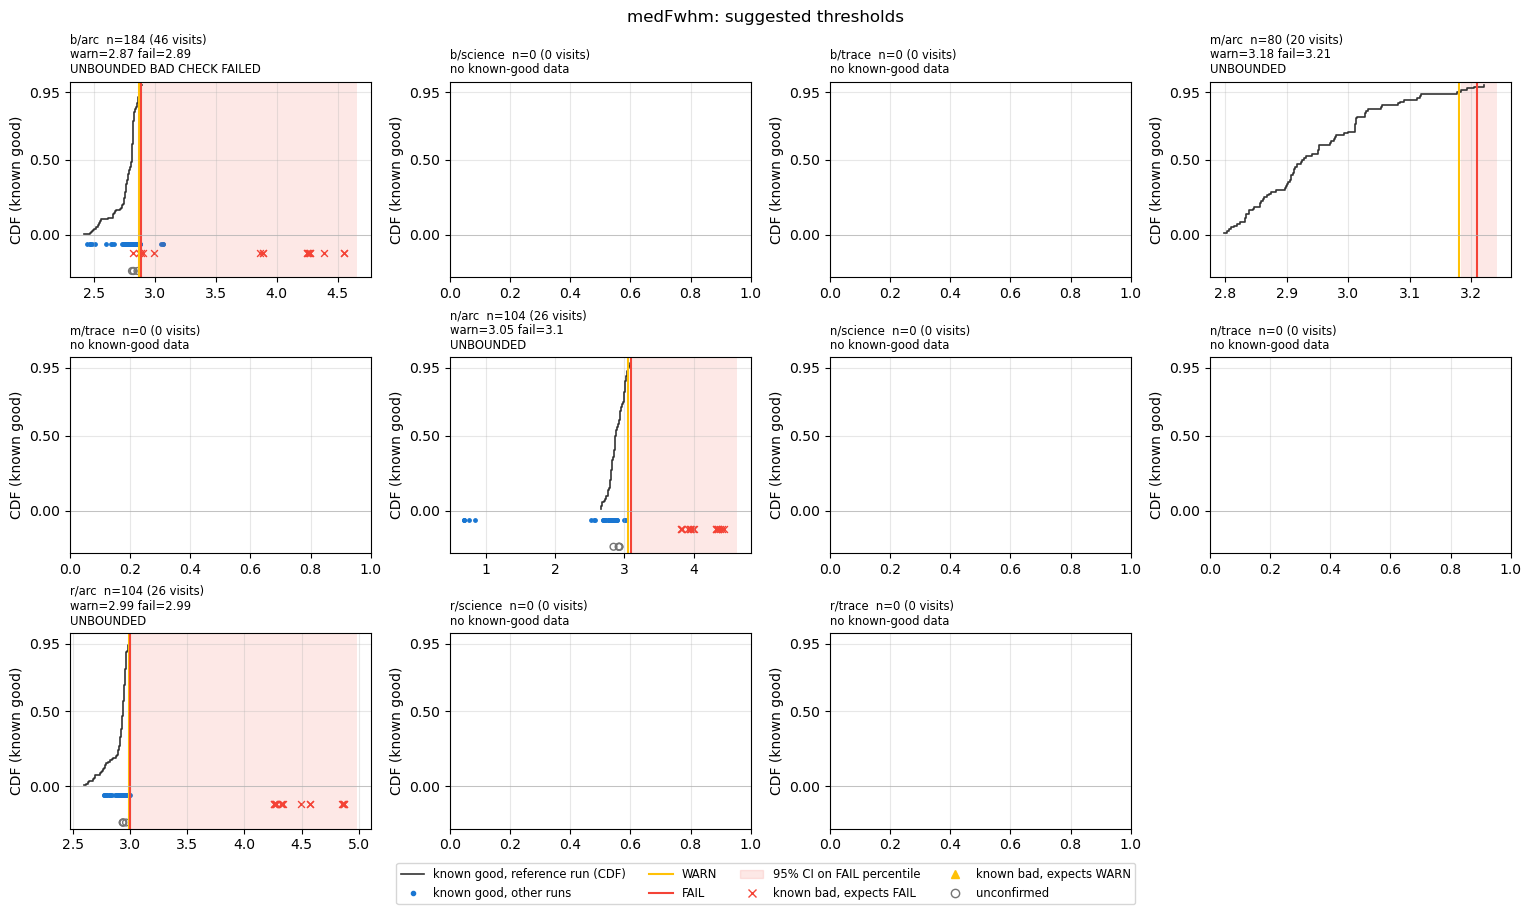

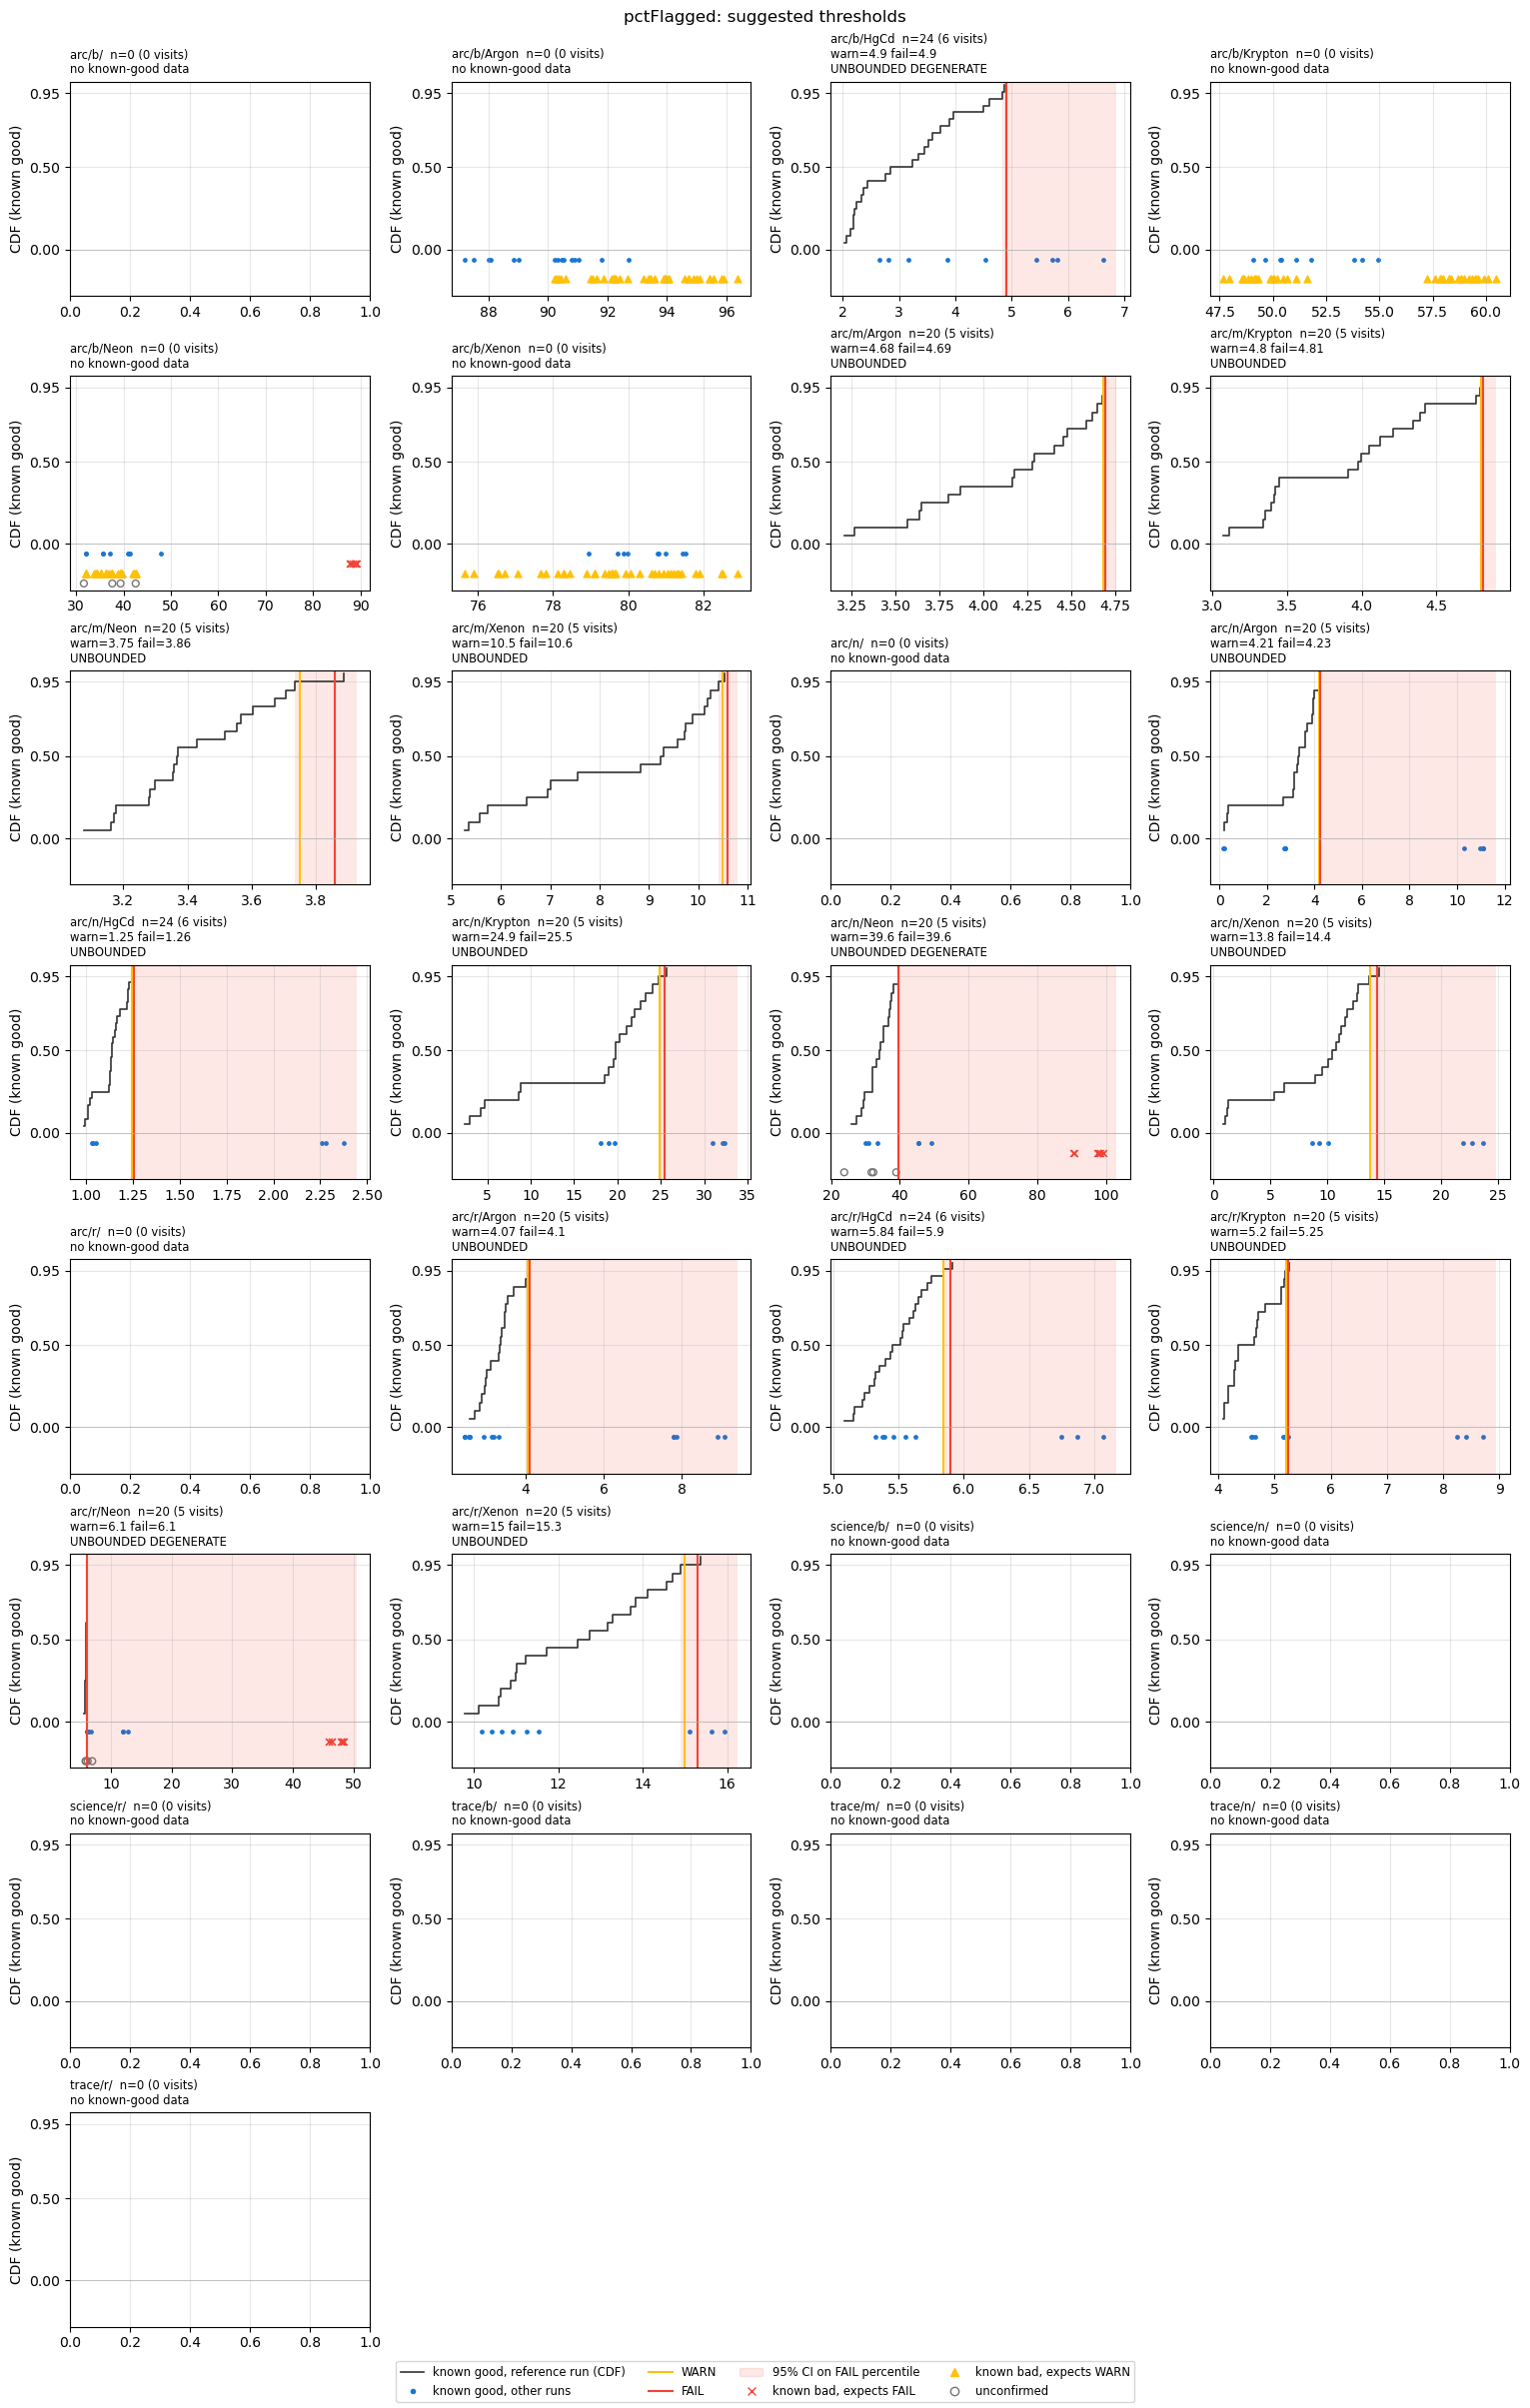

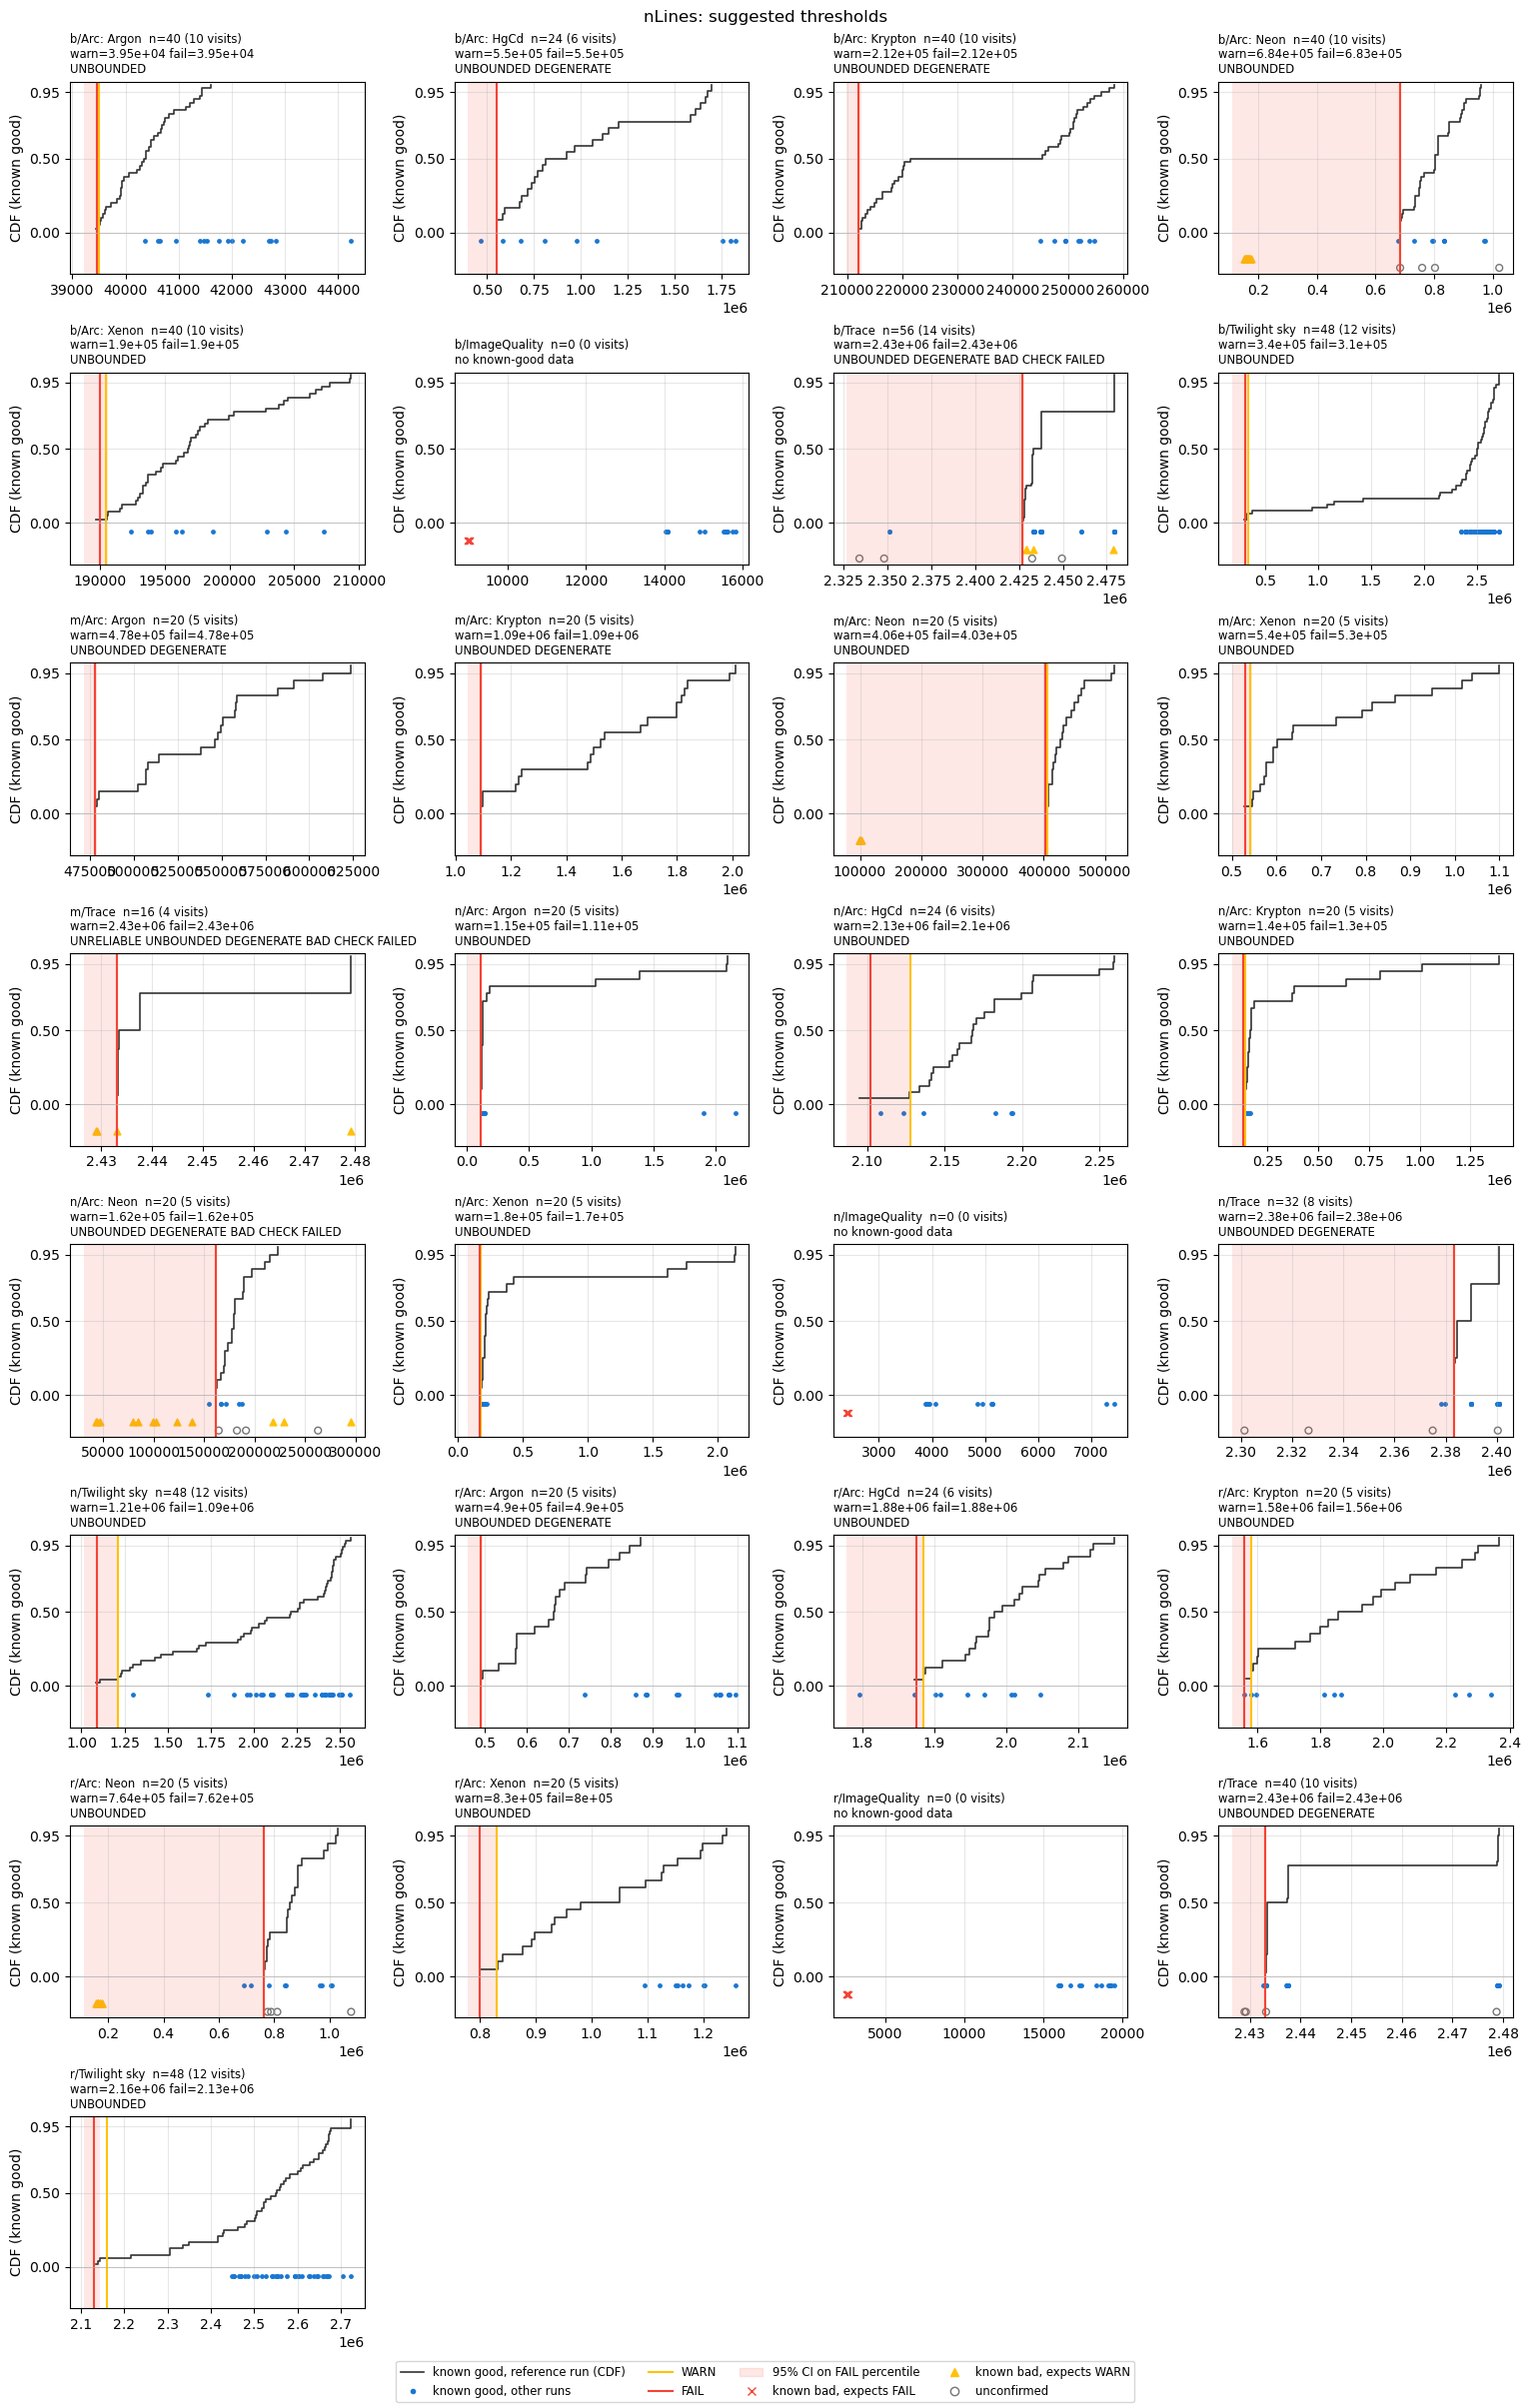

In [14]:
for metric in METRICS:
    labelled = labelRows(metrics, visitSet, metric)
    plotThresholds(labelled, table, metric, absolute=METRIC_SPECS[metric].absolute)
    plt.show()

The provenance sentences, for the `doc` of each threshold adopted:

In [15]:
for _, row in table[table["nGood"] > 0].iterrows():
    print(f"{row['metric']}[{row['group']}]: warn={row['warn']:g} fail={row['fail']:g}")
    print(f"    {row['provenance']}")

medFwhm[b/arc]: warn=2.872 fail=2.89
    Derived 2026-10-05 from validation visits 133025-135848 (n=184): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=184 cannot bound p99 at 95% confidence, so FAIL sits at the sample's extreme.
medFwhm[m/arc]: warn=3.18 fail=3.21
    Derived 2026-10-05 from validation visits 133042-135848 (n=80): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=80 cannot bound p99 at 95% confidence, so FAIL sits at the sample's extreme.
medFwhm[n/arc]: warn=3.05 fail=3.1
    Derived 2026-10-05 from validation visits 133025-135840 (n=104): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=104 cannot bound p99 at 95% confidence, so FAIL sits at the sample's extreme.
medFwhm[r/arc]: warn=2.987 fail=2.993
    Derived 2026-10-05 from validation visits 133025-135840 (n=104): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=104 cannot bound p99 at 95% confidence, so FAIL sits at the sample's extreme.
pctFlagged[arc/b/HgCd]: warn=4.9 fail=4.9
    Derived 2026-10-05 from validation visits 1330

The thresholds as a versioned file, for the judgement step and for review: one entry per
metric and population, with the collection, reference runs, drp_qa version and provenance.

In [16]:
import subprocess

describe = subprocess.run(
    ["git", "-C", os.environ.get("DRP_QA_DIR", ".."), "describe", "--always", "--dirty"],
    capture_output=True,
    text=True,
)
drpQaVersion = describe.stdout.strip() if describe.returncode == 0 else "unknown"
path = writeThresholds(
    table,
    FILES / f"iqQaThresholds-{STEM}.yaml",
    collection=COLLECTION,
    referenceRuns=visitSet.referenceRuns,
    drpQaVersion=drpQaVersion,
)
print(f"{path} (drp_qa {drpQaVersion})")

/home/wtg/.cache/drp_qa/iqQaThresholds-u_wtg_qa-thresholds_003.yaml (drp_qa w.2026.35-75-ge792efc-dirty)


## 7. Review

Go through these in order:

1. **Missing visits, sequence types and unmatched entries** (section 5). A missing visit or
   an unmatched entry is a check that didn't run; a sequence-type disagreement means a
   visit was reduced with the wrong config.
   An entry whose visits are present but which matches nothing has a wrong selector:
   compare its `seqType` with the `seqName` column, character for character.
2. **Known-bad checks.** In each population with known-bad rows, `badOk` must be true. If
   not, look at the panel: a marker on the good side of `FAIL` is a missed fault. Either the
   metric doesn't see this fault, or the visit isn't bad for the reason recorded. Fix
   whichever is wrong, not the threshold.
3. **Sample size.** `reliable` is false below 20 values. `nGoodVisits` is the more honest
   count: the detectors of one visit, and back-to-back exposures, are correlated.
4. **`failBounded`.** When false, the sample is too small to bound the FAIL percentile
   (about 370 values are needed for p99): its interval is open, and `FAIL` is an estimate
   near the sample's tail. Usable,
   but expect it to move as data accumulate; the provenance sentence says so.
5. **`degenerate`.** `WARN` is not below `FAIL`, so `WARN` can never fire. It comes from
   ties in the tail; set the pair by hand from the plot.
6. **Held-out runs.** `heldOutFlaggedFail` and the per-run table show how the thresholds
   do on data they were not derived from. A run flagged far more than the reference is a
   change to explain (calibrations, focus, a pipeline version), not a threshold to widen.
7. **In-sample flag rates.** `goodFlaggedWarn` and `goodFlaggedFail` should be near 5 % and
   1 %. Much more means ties at the threshold.
8. **Unconfirmed visits.** `unconfirmedFlagged` counts the suspected faults the suggestion
   would flag. Use it to settle them in the YAML ([`validation-visits.md`](validation-visits.md)),
   not to move a threshold.
9. **Populations without good data.** Rows with `nGood` 0 have known-bad visits and nothing
   to compare them with. Add known-good visits for that population, or accept that it goes
   unchecked.

## 8. Adopt

The thresholds are config fields of `ImageQualityQaConfig` in
`python/pfs/drp/qa/imageQualityQa.py`. Changing them changes verdicts, so it is done on a
ticket of its own (for the first derivation, PIPE2D-1917).

| Metric | Fields | Granularity | Populations it gates |
|---|---|---|---|
| `medFwhm` | `fwhmWarnThreshold`, `fwhmFailThreshold` | one value | every arm, except traces (not gated until PIPE2D-1917) |
| `medDxCenter` (absolute) | `dxCenterWarnThreshold`, `dxCenterFailThreshold` | one value | every arm and type |
| `pctFlagged` | `flagRateWarnThreshold`, `flagRateFailThreshold` | per `arm` or `arm:species` | as keyed |

1. Where a field holds one value but this notebook gives one per population, use the most
   lenient suggestion among the populations that field gates. Anything stricter fails good
   detectors in the widest population. Note the populations in the `doc`. The spread
   between populations is what a single value costs: a fault that reaches only the lenient
   population's threshold goes unflagged in the others.
2. Paste the provenance sentence (section 6) into the field's `doc`.
3. Update the threshold tables in the README (`imageQualityQa` → *Pass/Warn/Fail
   Thresholds*) and add a line under `## [Unreleased]` in `CHANGELOG.md`.
4. Run this notebook again with `RUN_PIPELINE = True` (a new numbered run) and the new defaults, and check that every
   known-good visit passes and every known-bad one gets its expected verdict.

## 9. Commit

Commit this notebook with its outputs on the ticket branch. It shows only validation visits,
which are engineering and calibration visits, so its outputs are fine to publish.

```bash
git add docs/qa-thresholds.ipynb
git commit
```